In [1]:
import json
import os
import urllib.request
import ssl
from typing import Any, List, Dict


def download_and_load_file(file_path: str, url: str) -> List[Dict[str, Any]]:
    """
    Download a JSON file from the given URL if it does not already exist locally,
    then load and return its contents as a Python list of dictionaries.

    This function:
      1. Creates an SSL context that does not verify certificates (useful for environments
         where SSL verification may fail).
      2. Checks if `file_path` exists:
         - If not, it opens the URL and writes the contents to `file_path`.
         - If it does, it skips the download to save bandwidth and I/O.
      3. Opens `file_path` and parses it as JSON.

    Args:
        file_path (str): Path on disk where the JSON file should be saved (or is already saved).
        url (str): The HTTP(S) URL from which to download the JSON file.

    Returns:
        List[Dict[str, Any]]: The parsed JSON content (expected to be a list of dicts).

    Raises:
        urllib.error.URLError: If the download fails (e.g., no internet connection, 404, etc.).
        json.JSONDecodeError: If the file cannot be parsed as valid JSON.
        OSError: For any file-system–related errors (e.g., insufficient permissions).
    """
    # Create an SSL context that skips certificate verification. This can be useful
    # in environments (e.g. some corporate networks) where certificate verification
    # might fail. For production code, you might want to remove/modify this for security.
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    # If the target directory does not exist, create it.
    os.makedirs(os.path.dirname(file_path) or ".", exist_ok=True)

    # Download the file only if it's not already on disk.
    if not os.path.exists(file_path):
        # Open the URL and read its bytes, then decode to UTF-8
        with urllib.request.urlopen(url, context=ssl_context) as response:
            raw_bytes = response.read()
            text_data = raw_bytes.decode("utf-8")

        # Write the downloaded text to disk
        with open(file_path, "w", encoding="utf-8") as out_file:
            out_file.write(text_data)
    else:
        # If the file already exists, we skip the download step.
        # Reading it later in JSON parsing step is sufficient.
        pass

    # At this point, file_path exists (either downloaded just now or was already present).
    # Load and parse the JSON file into a Python object.
    with open(file_path, "r", encoding="utf-8") as in_file:
        data = json.load(in_file)

    return data


In [2]:
file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

try:
    data = download_and_load_file(file_path, url)
except Exception as e:
    print(f"Error downloading or parsing '{file_path}': {e}")
    raise

print("Number of entries:", len(data))
# Inspect a sample entry to see its structure
print("Example entry:\n", data[10])


Number of entries: 1100
Example entry:
 {'instruction': 'What is the contraction for "will not"?', 'input': '', 'output': 'The contraction for "will not" is "won\'t".'}


In [3]:
import torch
from torch.utils.data import Dataset
from typing import List, Dict

def format_input(entry: Dict[str, str]) -> str:
    """
    Convert a single instruction‐response entry into the Alpaca‐style prompt string.

    Given an entry dictionary with keys:
      - "instruction": the instruction text (always present)
      - "input":      optional additional input text (might be an empty string)
    returns a string of the form:

        Below is an instruction that describes a task. Write a response that appropriately completes the request.

        ### Instruction:
        <entry["instruction"]>

        ### Input:
        <entry["input"]>   (only if entry["input"] is nonempty)

    Args:
        entry (Dict[str, str]): A dictionary with keys "instruction" and "input".

    Returns:
        str: The formatted prompt string (without the response).
    """
    # Base boilerplate for Alpaca‐style prompts
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        "\n\n### Instruction:\n" 
        f"{entry['instruction']}"
    )

    # If there is any additional "input" text, include it under "### Input"
    input_text = ""
    if entry.get("input", ""):
        input_text = f"\n\n### Input:\n{entry['input']}"

    return instruction_text + input_text



In [4]:


# Suppose 'data' is a list of entries loaded from the JSON:
# data[50] might look like:
# {
#     "instruction": "Translate to German: 'How are you today?'",
#     "input": "This sentence is part of a larger conversation in Berlin.",
#     "output": "Wie geht es Ihnen heute?"
# }

# Format just the prompt
entry = data[50]
model_input = format_input(entry)

# The desired model response is prepended by "### Response:\n"
desired_response = f"\n\n### Response:\n{entry['output'].strip()}"

# Print the full Alpaca‐style example
print(model_input + desired_response)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [5]:
import random
from typing import List, Dict

def split_dataset(
    data: List[Dict[str, str]],
    train_frac: float = 0.85,
    val_frac: float = 0.05,
    test_frac: float = 0.10,
    seed: int = 123
) -> (List[Dict[str, str]], List[Dict[str, str]], List[Dict[str, str]]):
    """
    Split a list of instruction‐response entries into train/validation/test subsets.

    Args:
        data (List[Dict[str, str]]):
            The full dataset as a list of dictionaries, e.g.
            [{"instruction": "...", "input": "...", "output": "..."}, ...].
        train_frac (float): Proportion of data to allocate to the training set.
        val_frac (float): Proportion of data to allocate to the validation set.
        test_frac (float): Proportion of data to allocate to the test set.
                          Note that train_frac + val_frac + test_frac should ≈ 1.0.
        seed (int): Random seed for reproducible shuffling.

    Returns:
        Tuple of three lists (train_data, val_data, test_data), each being a subset of `data`.
        The lengths will be (approximately) train_frac * len(data), val_frac * len(data),
        and test_frac * len(data), with any rounding discrepancies assigned to the validation set.

    Raises:
        ValueError: If the three fractions do not sum to 1.0 (within a small tolerance),
                    or if any fraction is negative.

    Example:
        >>> full_data = [{"instruction": "A", "input": "", "output": "1"},
        ...              {"instruction": "B", "input": "x", "output": "2"},
        ...              {"instruction": "C", "input": "y", "output": "3"},
        ...              ...]
        >>> train_set, val_set, test_set = split_dataset(full_data, train_frac=0.8, val_frac=0.1, test_frac=0.1)
        >>> len(train_set), len(val_set), len(test_set)
        (880, 110, 110)      # for a dataset of length 1100
    """
    # Validate that fractions sum to 1.0 (tolerance for floating‐point arithmetic)
    total_frac = train_frac + val_frac + test_frac
    if not abs(total_frac - 1.0) < 1e-6:
        raise ValueError(f"train_frac + val_frac + test_frac must sum to 1.0, got {total_frac:.6f}")

    if any(frac < 0.0 for frac in (train_frac, val_frac, test_frac)):
        raise ValueError("Fractions must be non‐negative.")

    # Make a reproducible copy of the data and shuffle in place
    data_copy = data[:]  # shallow copy is enough since we don’t modify entries themselves
    random.Random(seed).shuffle(data_copy)

    n = len(data_copy)
    # Compute split indices, rounding down for train and test
    train_end = int(n * train_frac)
    test_end = train_end + int(n * test_frac)

    # Slice out the splits
    train_data = data_copy[:train_end]
    test_data = data_copy[train_end:test_end]
    val_data = data_copy[test_end:]  # Any remainder goes to validation

    return train_data, val_data, test_data


In [6]:
# Assume `data` is a list of 1100 instruction‐response entries loaded from JSON
train_data, val_data, test_data = split_dataset(
    data,
    train_frac=0.85,
    val_frac=0.05,
    test_frac=0.10,
    seed=123
)

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


Training set length: 935
Validation set length: 55
Test set length: 110


In [7]:
import torch
from torch.utils.data import Dataset
from typing import List, Dict


class InstructionDataset(Dataset):
    """
    A PyTorch Dataset for instruction‐response fine‐tuning in Alpaca style.

    Each entry in `data` should be a dictionary with:
        - "instruction": str, the task description or instruction.
        - "input":       str, optional input for the instruction (may be empty).
        - "output":      str, the expected response text.

    This Dataset:
      1. Formats each entry into an Alpaca‐style prompt string by calling `format_input`.
      2. Appends the response text prefixed by "### Response:\n" to the prompt.
      3. Tokenizes the combined prompt+response string via `tokenizer.encode(...)`.
      4. Ensures there is exactly one EOS token (`eos_token_id`) at the end of the token list.
      5. Stores the resulting list of token IDs in memory; `__getitem__` simply returns that list.

    A custom collate function (see notebook) will pad these variable‐length token lists
    into a uniform batch tensor at training time.

    Attributes:
        data (List[Dict[str, str]]):
            The raw instruction‐response entries.
        tokenizer:
            A tokenization object with an `.encode(str) -> List[int]` method (e.g., tiktoken).
        eos_token_id (int):
            The token ID used to mark end‐of‐text (EOS). Defaults to 50256 for GPT-2.
        encoded_texts (List[List[int]]):
            Pre‐tokenized examples: each element is the full prompt+response as a list of IDs,
            guaranteed to end with `eos_token_id`.
    """

    def __init__(
        self,
        data: List[Dict[str, str]],
        tokenizer,
        eos_token_id: int = 50256
    ) -> None:
        """
        Initialize the InstructionDataset.

        For each entry in `data`:
          1. Call `format_input(entry)` to build the Alpaca‐style instruction prompt.
          2. Append the response segment prefixed by "### Response:\n".
          3. Tokenize the entire string into a list of token IDs.
          4. If the token list does not end in `eos_token_id`, append `eos_token_id`
             so that the model learns to generate an explicit end‐of‐text marker.

        Args:
            data (List[Dict[str, str]]):
                List of raw entries, each a dict with keys "instruction", "input", "output".
            tokenizer:
                A tokenizer providing `.encode(text: str) -> List[int]`.
            eos_token_id (int, optional):
                The ID of the end‐of‐text token. Defaults to 50256 (GPT-2’s EOS).
        """
        self.data = data
        self.tokenizer = tokenizer
        self.eos_token_id = eos_token_id

        # Pre‐tokenize each example into a list of token IDs
        self.encoded_texts: List[List[int]] = []
        for entry in data:
            # 1) Build the Alpaca‐style instruction prompt
            #    format_input concatenates:
            #      - A boilerplate: "Below is an instruction... Write a response..."
            #      - "### Instruction:\n" followed by entry["instruction"]
            #      - If entry["input"] is nonempty, "### Input:\n" + entry["input"]
            prompt_text = format_input(entry)

            # 2) Append the "### Response:" prefix and the actual output text
            response_text = f"\n\n### Response:\n{entry['output']}"

            # 3) Combine prompt + response into one continuous string
            full_text = prompt_text + response_text

            # 4) Tokenize into a list of IDs
            token_ids = tokenizer.encode(full_text)

            # 5) Ensure exactly one EOS at the end:
            #    - If the list is empty (unlikely), or the last token is not EOS, append it.
            if not token_ids or token_ids[-1] != self.eos_token_id:
                token_ids.append(self.eos_token_id)

            # 6) Save the final token list
            self.encoded_texts.append(token_ids)

    def __getitem__(self, index: int) -> List[int]:
        """
        Retrieve the token ID list for a single example.

        Args:
            index (int): Index of the example to retrieve.

        Returns:
            List[int]: A list of token IDs representing the full prompt+response,
                       guaranteed to end in `eos_token_id`.
        """
        return self.encoded_texts[index]

    def __len__(self) -> int:
        """
        Return the total number of examples in this dataset.

        Returns:
            int: Number of entries (length of `encoded_texts`).
        """
        return len(self.encoded_texts)


In [8]:
import torch
from typing import List, Optional, Tuple


def custom_collate_fn(
    batch: List[List[int]],
    pad_token_id: int = 50256,
    ignore_index: int = -100,
    allowed_max_length: Optional[int] = None,
    device: str = "cpu"
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Custom collate function to convert a list of token‐ID sequences into padded input
    and target tensors for instruction‐tuning. 

    This function performs:
      1. Finds the length of the longest sequence in the batch (plus one extra token).
      2. For each sequence:
         a. Appends exactly one EOS/pad token at the end.
         b. Pads the result to `batch_max_length` using `pad_token_id`.
         c. Creates `inputs` by dropping the last token (shifted left by one).
         d. Creates `targets` by dropping the first token (shifted right by one).
         e. Replaces all but the first occurrence of `pad_token_id` in `targets` 
            with `ignore_index` so these tokens do not contribute to cross‐entropy loss.
         f. Optionally truncates `inputs` and `targets` to `allowed_max_length`.
      3. Stacks all per‐example `inputs` into a (batch_size, seq_len) tensor.
      4. Stacks all per‐example `targets` into a (batch_size, seq_len) tensor.
      5. Moves both tensors to the specified `device`.

    Why the extra EOS token and shifting?
      - By appending one EOS token before padding, we ensure every sequence ends with at least
        one end‐of‐text marker. That final token is used both in `inputs` (as the last “next‐token”
        prompt) and in `targets` (as the first real EOS label). Everything past the first EOS in
        `targets` is marked with `ignore_index` to avoid computing loss on padding.
      - We drop the last token from `inputs` because we want to predict “next‐token” at each position:
        `inputs[i]` should predict `targets[i]`. Hence the shift.

    Args:
        batch (List[List[int]]):
            A list of examples, where each example is a list of token IDs (prompt + response),
            already guaranteed to end in EOS or full text.
        pad_token_id (int, optional):
            The token ID used for padding (and also the EOS ID in GPT‐2). Defaults to 50256.
        ignore_index (int, optional):
            The value to assign to padded target positions so that the loss function
            ignores them. Defaults to -100 (PyTorch’s typical ignore_index).
        allowed_max_length (Optional[int], optional):
            If not None, truncates both `inputs` and `targets` to this maximum length.
            Useful if your data might exceed the model’s context window (e.g., 1024 tokens).
        device (str, optional):
            The device on which to place the resulting tensors (e.g., "cpu" or "cuda").
            Defaults to "cpu".

    Returns:
        Tuple[torch.Tensor, torch.Tensor]:
            - inputs_tensor:  Tensor of shape (batch_size, seq_len) with padded input IDs.
            - targets_tensor: Tensor of shape (batch_size, seq_len) with padded target IDs,
                              where padding positions (after the first EOS) are set to ignore_index.
    """
    # 1) Determine the length to which we will pad every sequence:
    #    We add +1 so that we can append one EOS/pad token before padding to the max.
    batch_max_length = max(len(seq) + 1 for seq in batch)

    inputs_list: List[torch.Tensor] = []
    targets_list: List[torch.Tensor] = []

    for seq in batch:
        # 2a) Make a copy and append exactly one EOS token to guarantee an end‐of‐text marker
        seq_with_eos = seq.copy()
        seq_with_eos.append(pad_token_id)

        # 2b) Pad to batch_max_length using pad_token_id
        num_padding = batch_max_length - len(seq_with_eos)
        padded_seq = seq_with_eos + [pad_token_id] * num_padding  # length=batch_max_length

        # 2c) `inputs` is everything except the last token
        #     (so model is prompted to predict the final EOS at the last position)
        inputs = torch.tensor(padded_seq[:-1], dtype=torch.long)

        # 2d) `targets` is everything except the first token (shifted right by one)
        targets = torch.tensor(padded_seq[1:], dtype=torch.long)

        # 2e) Replace all but the first occurrence of pad_token_id in `targets` with ignore_index
        #     so that only the first EOS (if any) remains for loss computation.
        #     Any subsequent pad_token_id is purely padding and should not contribute to loss.
        pad_mask = (targets == pad_token_id).nonzero(as_tuple=False).squeeze(dim=-1)
        if pad_mask.numel() > 1:
            # Keep the first pad index intact (to let model learn when to generate EOS),
            # replace later padding indices with ignore_index
            first_pad_idx = pad_mask[0].item()
            subsequent_pad_indices = pad_mask[1:]
            targets[subsequent_pad_indices] = ignore_index

        # 2f) Optionally truncate to allowed_max_length (e.g. 1024 for GPT‐2 context)
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_list.append(inputs)
        targets_list.append(targets)

    # 3) Stack into final batch tensors and move to target device
    inputs_tensor = torch.stack(inputs_list, dim=0).to(device)
    targets_tensor = torch.stack(targets_list, dim=0).to(device)

    return inputs_tensor, targets_tensor


In [9]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [10]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [11]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [12]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [14]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024  # truncate or pad sequences to GPT-2's 1024‐token limit
)

In [15]:
# ---------------------------------------------------------------------------------
# Now, set up the DataLoaders for training, validation, and test sets.
# We use `InstructionDataset` (defined previously) to wrap raw data lists.
#
# Key Points:
#  - shuffle=True for training, so that batches are randomized each epoch.
#  - drop_last=True for training, so that partial batches at the end are dropped
#    (helps keep batch normalization or gradient accumulation consistent).
#  - num_workers=0 is used here to avoid potential issues on some platforms;
#    feel free to increase if you have multiple CPU cores and large datasets.
# ---------------------------------------------------------------------------------

from torch.utils.data import DataLoader
import tiktoken

# Load Tokenizer 
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)

# Hyperparameters
num_workers = 0
batch_size = 8
torch.manual_seed(123)  # For reproducibility (affects shuffle order)

# Instantiate the Dataset objects
train_dataset = InstructionDataset(train_data, tokenizer)
val_dataset = InstructionDataset(val_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,               # Shuffle training data each epoch
    drop_last=True,             # Drop incomplete batch at end
    collate_fn=customized_collate_fn,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,              # No need to shuffle validation set
    drop_last=False,            # Keep all validation examples
    collate_fn=customized_collate_fn,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,              # No shuffle for test set
    drop_last=False,            # Keep all test examples
    collate_fn=customized_collate_fn,
    num_workers=num_workers
)


In [16]:
# ---------------------------------------------------------------------------------
# Verify the shapes of a single batch from the training loader. Each iteration
# of train_loader yields `(inputs, targets)` where:
#   - inputs:  Tensor of shape (batch_size, seq_length)
#   - targets: Tensor of shape (batch_size, seq_length)
# ---------------------------------------------------------------------------------

print("Train loader batch shapes:")
for inputs, targets in train_loader:
    print("  inputs shape:", inputs.shape)
    print("  targets shape:", targets.shape)


Train loader batch shapes:
  inputs shape: torch.Size([8, 66])
  targets shape: torch.Size([8, 66])
  inputs shape: torch.Size([8, 64])
  targets shape: torch.Size([8, 64])
  inputs shape: torch.Size([8, 84])
  targets shape: torch.Size([8, 84])
  inputs shape: torch.Size([8, 62])
  targets shape: torch.Size([8, 62])
  inputs shape: torch.Size([8, 70])
  targets shape: torch.Size([8, 70])
  inputs shape: torch.Size([8, 61])
  targets shape: torch.Size([8, 61])
  inputs shape: torch.Size([8, 77])
  targets shape: torch.Size([8, 77])
  inputs shape: torch.Size([8, 68])
  targets shape: torch.Size([8, 68])
  inputs shape: torch.Size([8, 69])
  targets shape: torch.Size([8, 69])
  inputs shape: torch.Size([8, 73])
  targets shape: torch.Size([8, 73])
  inputs shape: torch.Size([8, 66])
  targets shape: torch.Size([8, 66])
  inputs shape: torch.Size([8, 84])
  targets shape: torch.Size([8, 84])
  inputs shape: torch.Size([8, 64])
  targets shape: torch.Size([8, 64])
  inputs shape: torch.Si

In [17]:
# 1. Standard library imports
import logging
import os
import time
from typing import Dict, List, Optional, Tuple

# 2. Related third-party imports
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
from tqdm import tqdm
import tiktoken


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [18]:

class Head(nn.Module):
    """
    A single self-attention head for a Transformer model with causal masking.

    This module implements the core attention mechanism described in the 
    "Attention Is All You Need" paper, with modifications for causal masking to 
    prevent future context leakage in autoregressive models. The implementation
    uses a fused QKV projection for computational efficiency.

    Attributes:
        qkv_proj (nn.Linear): Fused projection layer for query, key, and value vectors
        tril (torch.Tensor): Lower triangular causal mask buffer
        dropout (nn.Dropout): Dropout layer for attention weights regularization
        head_size (int): Dimensionality of key/query/value vectors
    """

    def __init__(self, n_embd: int, head_size: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize the self-attention head with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings (C)
            head_size (int): Dimension size of query/key/value projections (H)
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability (0.0-1.0) for attention weights
            qkv_bias (bool): Whether to include biases for Q, K, and V projections
            
        Notes:
            - Uses fused QKV projection (3H) instead of 3 separate H projections
            - head_size must divide n_embd evenly for effective projection
        """
        super().__init__()

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3H
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * head_size, bias=qkv_bias)
        
        # Causal Attention Mask Buffer
        # Register a lower triangular matrix that prevents "peeking ahead"
        # Shape: (block_size, block_size)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # Attention Weights Dropout
        # Applied after softmax to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Store head_size for scaling in attention computation
        self.head_size = head_size

    # x Tensor shape (batch_size, time_steps, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute self-attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (B, T, C)
                B = batch size
                T = sequence length
                C = embedding dimension

        Returns:
            Tensor: Output tensor of shape (B, T, H)
                H = head_size (dimension of value vectors)
        """
        # Get input dimensions
        # B=batch_size, T=sequence_length, C=embedding_dim
        B,T,C = x.shape

        # Linear Projections
        # Fused QKV: (B, T, C) -> (B, T, 3 * head_size)
        qkv = self.qkv_proj(x)

        # Split into Query, Key, Value
        # Each projection is (B, T, H) where H = head_size
        head_size = qkv.size(-1) // 3
        q, k, v = qkv.split(head_size, dim=2)

        # Scaled Dot-Product Attention
        # 1. Compute raw attention scores: (B, H, T, T)
        #    q: (B, T, H) 
        #    k: (B, T, H) → transpose to (B, H, T)
        #    q @ k.T: (B, T, H) @ (B, H, T) → (B, T, T)
        wei = q @ k.transpose(-2,-1) # (B, T, head_size) @ (B, head_size, T) => (B, T, T)
        scale_factor = (head_size ** -0.5) # sqrt(head_size) for stability
        wei_scaled = wei / scale_factor     # Scaling prevents extreme values

        # 2. Apply causal masking to prevent future token attention
        #    Masked positions are set to -inf to zero out softmax probabilities
        #    Crop mask to current sequence length T
        wei_scaled = wei_scaled.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mark upper triangle (forbidden)

        # 3. Softmax normalization to get probabilities
        # Large negative values (-inf) become zero after softmax
        att_weights = F.softmax(wei_scaled, dim=-1)  # (B, T, T)

        # 4. Apply dropout to attention probabilities
        # Dropout randomly nullifies connections for regularization
        att_weights_dropped = self.dropout(att_weights)
        
        # Value Matrix Multiplication
        # Output: (B, T, T) @ (B, T, H) → (B, T, H)
        # (B, T, H) = (B, T, T) @ (B, T, H)
        out = att_weights_dropped @ v

        return out


class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention module with causal masking for Transformer models.

    This implementation performs parallel self-attention across multiple heads using:
    1. A fused QKV projection for computational efficiency
    2. Multi-head decomposition for parallel attention computation
    3. Causal masking to prevent future context leakage in autoregressive models
    4. Final projection with residual connection and dropout

    The module follows the standard Transformer attention mechanism but with:
    - Fused QKV projection (single linear layer)
    - Causal masking for language modeling
    - Parallel attention heads with head sharing

    Args:
        n_embd (int): Total embedding dimension of input features
        num_heads (int): Number of attention heads to use
        block_size (int): Maximum sequence length for causal masking
        dropout (float): Dropout rate for attention weights and output projection
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        num_heads (int): Number of attention heads
        head_size (int): Dimension of each attention head (n_embd // num_heads)
        qkv_proj (nn.Linear): Fused QKV projection layer (output dimension: 3 * n_embd)
        out_proj (nn.Linear): Final projection layer (output dimension: n_embd)
        attn_dropout (nn.Dropout): Dropout layer for attention weights
        resid_dropout (nn.Dropout): Dropout layer for final output projection
        tril (torch.Tensor): Causal mask buffer (block_size x block_size)
    """

    def __init__(self, n_embd: int, num_heads: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize multi-head attention module with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings
            num_heads (int): Number of parallel attention heads
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability for regularization
            qkv_bias (bool): Whether to include biases for Q, K, and V projections  
            
        Raises:
            AssertionError: If n_embd is not divisible by num_heads
            
        Notes:
            - Uses fused QKV projection (3*n_embd) instead of separate projections
            - head_size is automatically computed as n_embd // num_heads
            - Causal mask is registered as buffer for efficient sequence length slicing
        """
        super().__init__()

        # Validate head count compatibility
        assert n_embd % num_heads == 0, "Input embedding dimension must be divisible by number of heads"

         # Store configuration
        self.num_heads = num_heads
        self.head_size = n_embd // num_heads  # Automatically compute head size

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3*n_embd
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd, bias=qkv_bias)

        # Final Output Projection
        # Projects concatenated multi-head outputs back to original embedding dimension
        self.out_proj = nn.Linear(n_embd, n_embd, bias=qkv_bias)

        # Regularization Layers
        # Attention dropout: applied to softmax probabilities
        self.attn_dropout = nn.Dropout(dropout)
        # Residual dropout: applied after final projection
        self.resid_dropout = nn.Dropout(dropout)

        # Causal Attention Mask Buffer
        # Register a lower triangular matrix that prevents "peeking ahead"
        # Shape: (block_size, block_size)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute multi-head attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_length, n_embd)
                - batch_size (B): Number of sequences in batch
                - seq_length (T): Length of each sequence
                - n_embd (C): Embedding dimension

        Returns:
            Tensor: Output tensor of same shape (B, T, C) after attention and projection
        """
        # Get input dimensions
        B, T, C = x.size()

        # 1. Fused QKV Projection
        # Input: (B, T, C) -> Output: (B, T, 3*C)
        # Projects to concatenated [Q; K; V] vectors
        qkv = self.qkv_proj(x)

        # 2. Split into Query, Key, Value
        # Each projection is (B, T, C) where C = n_embd
        q, k, v = qkv.chunk(3, dim=2)

        # 3. Reshape for Multi-Head Attention
        # (B, T, C) -> (B, heads, T, head_size)
        # 1. View: (B, T, C) -> (B, T, heads, head_size)
        # 2. Transpose: (B, T, heads, head_size) -> (B, heads, T, head_size)
        q = q.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_size).transpose(1, 2)

        # # vvvvvvvvvvvvvvvvvvvvvvvvv
        # # 4. Scaled Dot-Product Attention
        # # Compute attention scores: Q @ K^T / sqrt(head_size)
        # # (B, heads, T, head_size) @ (B, heads, head_size, T) -> (B, heads, T, T)
        # att = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)

        # # 5. Apply Causal Masking
        # # Expand mask to (1, 1, T, T) for broadcasting across batch and head dimensions
        # # Masked positions are set to -inf to zero out softmax probabilities
        # mask = self.tril[:T, :T].view(1, 1, T, T)
        # att = sa.masked_fill(mask == 0, float('-inf'))

        # # 6. Softmax Normalization
        # # Convert to attention probabilities
        # att = F.softmax(att, dim=-1)

        # # 7. Apply Attention Dropout
        # att = self.attn_dropout(att)

        # # 8. Weighted Value Vectors
        # # (B, heads, T, T) @ (B, heads, T, head_size) -> (B, heads, T, head_size)
        # out = att @ v
        # # ^^^^^^^^^^^^^^^^^^^^^^^^^^
        # using FlashAttention for steps 4. to 8.
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=self.attn_dropout.p if self.training else 0.0)

        # 9. Concatenate Attention Heads
        # (B, heads, T, head_size) -> (B, T, heads*head_size) = (B, T, C)
        # Use contiguous() before view() to ensure memory layout compatibility
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # 10. Final Output Projection
        # (B, T, C) -> (B, T, C)
        # Apply residual dropout before returning
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        
        return out


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.GELU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """
    Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        super().__init__()
        # Validate head count compatibility
        assert n_embd % n_head == 0, "Input embedding dimension must be divisible by number of heads"

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            block_size=block_size,
            dropout=dropout,
            qkv_bias=qkv_bias
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd)         # Normalization after attention
        self.ln2 = nn.LayerNorm(n_embd)         # Normalization after feed-forward
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """
        # # vvvvvvvvvvvv original vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
        # # 1. Self-Attention sublayer
        # y = self.sa(x)          # Compute multi-head attention
        # x = self.ln1(x + y)     # Add residual connection + normalize
        
        # # 2. Feed-Forward sublayer
        # y = self.ffwd(x)        # Non-linear bottleneck
        # x = self.ln2(x + y)     # Residual + normalization
        # # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        # vvvvvvvvvvvv torch.utils.checkpoint  vvvvvvvvvvvvvvvvvvvv
        if self.training:
            # 1. Self-Attention sublayer with checkpointing to save memory
            y = checkpoint(self.sa, x) # Compute multi-head attention
        else:
            y = self.sa(x) # directly call without checkpoint in eval mode
        x = self.ln1(x + y) # Add residual connection + normalize

        if self.training:
            # 2. Feed-Forward sublayer with checkpointing
            y = checkpoint(self.ffwd, x) # Non-linear bottleneck
        else:
            y = self.ffwd(x) # directly call without checkpoint in eval mode
        x = self.ln2(x + y) # Residual + normalization
        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.
    
    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        qkv_bias: bool = False,       
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            qkv_bias (bool): Whether to include biases for Q, K, and V projections (default: False)
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device

        # 1) Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # 2) how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # 3) Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout, qkv_bias) 
            for _ in range(n_layer)
        ])

        # 4) Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        # 5) Output head with NO bias (to simplify tying)
        # This projects from hidden_dim → vocab_size
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=qkv_bias) # Predict next token probabilities

        # Optional
        # 6) Tie weights: share the same weight matrix as token embeddings
        #    Now lm_head.weight and token_embedding_table.weight are the same tensor
        self.lm_head.weight = self.token_embedding_table.weight

        # 7) Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian with σ=0.02)
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Create a range tensor up to current T (dynamic slicing for varying input lengths)
        tok_positions = torch.arange(T, device=self.device)
        pos_emb = self.position_embedding_table(tok_positions) # (T,C)

        # 3. Combine embeddings with element-wise addition → (B, T, C)
        x = tok_emb + pos_emb # (B,T,C)

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        if targets is None:
            loss = None
        else:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(self, input_tokens: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generate new tokens autoregressively using greedy sampling.
        
        Args:
            input_tokens (Tensor): Starting token sequence (B, T_0)
            max_new_tokens (int): Number of tokens to generate
        
        Returns:
            Tensor: Extended sequence including generated tokens (B, T_0 + max_new_tokens)
        """
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):

            # Crop input to model's maximum context length
            cropped_input = input_tokens[:, -self.block_size:]

            # Get full logits and ignore loss (targets not provided)
            logits, _ = self(cropped_input)

            # Get next token predictions from last time-step's output
            # Shape narrowing (B, T, C) → (B, 1, C)
            logits = logits[:, -1, :] # becomes (B,C)

            # Convert logits to probabilities (axis=-1 ensures proper normalization)
            probs = F.softmax(logits, dim=-1) # (B,C)

            # Sample one token index from distribution
            next_token = torch.multinomial(probs, num_samples=1) # (B,1)

            # Extend the sequence with new prediction
            input_tokens = torch.cat((input_tokens, next_token), dim=1) # (B,T+1)

        return input_tokens
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None,
        eos_token_id: int = 50256
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """
        
        for _ in range(max_new_tokens):
            # Context window clipping
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Apply top-k sampling (if requested)
            if top_k is not None:
                # Find top-k values and set others to -inf
                top_k_values, _ = torch.topk(scaled_logits, min(top_k, scaled_logits.size(-1)))
                mask = scaled_logits < top_k_values[:, [-1]]  # Broadcast comparison
                scaled_logits[mask] = -float("inf")

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Shift mask to apply to the appropriate tokens (keeps min. prob mass p)
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_indices_to_remove)

                # Set probabilities of removed tokens to zero and normalize
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

            # If we generated EOS, stop immediately
            if next_token.item() == eos_token_id:
                break

        return input_tokens  # Final expanded tensor
    


In [19]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(encoding_name: str) -> int:
    """
    Return the vocabulary size for a given encoding in tiktoken.

    Args:
        encoding_name: Name of the encoding (e.g. "gpt2", "cl100k_base", etc.)

    Returns:
        The total number of tokens in that encoding’s vocabulary.
    """
    encoding = tiktoken.get_encoding(encoding_name)
    return encoding.n_vocab


# -- Batch Extraction Function ------------------------------------------
def get_batch_for_training(
    batch_idx: int,
    data: np.ndarray,
    window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Extract a batch of overlapping sequences for model training.

    Args:
        batch_idx: Index of the batch to retrieve.
        data: NumPy array or memmap of token IDs.
        window_starts: List of start indices for sliding windows.
        block_size: Number of tokens per input sequence.
        batch_size: Number of sequences per batch.
        device: Torch device (cpu or cuda).

    Returns:
        x_batch: Tensor of shape (batch_size, block_size).
        y_batch: Tensor of shape (batch_size, block_size), one-step-shifted targets.
    """
    # Determine which window starts belong to this batch
    starts = window_starts[batch_idx * batch_size : (batch_idx + 1) * batch_size]
    # Gather input and target sequences
    x_np = np.stack([data[s : s + block_size] for s in starts])
    y_np = np.stack([data[s + 1 : s + block_size + 1] for s in starts])
    # Convert to Torch tensors on the target device
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# --- Sample a random batch for loss estimation --------------------------------
def get_batch_for_loss_estimation(
    split: str,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Sample one random batch for loss estimation from train or validation split.

    Args:
        split: 'train' or 'val'.
        data: Full token array (NumPy or memmap).
        split_index: Index separating train/validation data.
        block_size: Context window length.
        batch_size: Number of sequences per batch.
        device: Torch device.

    Returns:
        x_batch, y_batch: Torch tensors of shape (batch_size, block_size).
    """
    # Define slice boundaries based on split
    if split == 'train':
        start_i, end_i = 0, split_index
    else:
        start_i, end_i = split_index, len(data)
    # Compute how many full blocks are available
    num_blocks = (end_i - start_i - 1) // block_size
    # Randomly sample block indices
    idxs = torch.randint(0, num_blocks, (batch_size,), device=device)

    x_list, y_list = [], []
    # Build sequences for each sampled index
    for idx in idxs:
        off = start_i + idx.item() * block_size
        x_list.append(data[off : off + block_size])
        y_list.append(data[off + 1 : off + block_size + 1])
    # Stack and convert to tensors
    x_np = np.stack(x_list)
    y_np = np.stack(y_list)
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss(
    model,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: str,
    eval_iters: int = 50
) -> Dict[str, float]:
    """
    Compute average loss on `eval_iters` random batches from both train/val splits.

    Args:
        model:       GPTLanguageModel in eval mode
        data:        full token array
        split_index: boundary index between train/val
        block_size:  context window length
        batch_size:  number of windows per batch
        device:      torch device
        eval_iters:  how many batches to sample per split

    Returns:
        dict with keys 'train' and 'val' mapping to average loss
    """
    losses = {}
    model.eval()

    for split in ('train', 'val'):
        total = 0.0
        for _ in range(eval_iters):
            X, Y = get_batch_for_loss_estimation(
                split, data, split_index, block_size, batch_size, device
            )
            # mixed-precision inference
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
            total += loss.item()
        losses[split] = total / eval_iters

    model.train()
    return losses


# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    batches_seen: List[int],
    train_losses: List[float],
    val_losses: List[float],
    file_path: str,
    scaler: torch.cuda.amp.GradScaler = None  # Optional scaler argument
) -> None:
    """ 
    Save model, optimizer, scaler (optional), and training history to disk for later resumption and plotting.

    Args:
        model (torch.nn.Module): Trained GPTLanguageModel.
        optimizer (torch.optim.Optimizer): Associated optimizer (e.g., AdamW).
        epoch (int): Current epoch or step number.
        loss (float): Latest loss value.
        batches_seen (List[int]): List of batch-indices at which evals were performed.
        train_losses (List[float]): Recorded training losses at each eval point.
        val_losses (List[float]): Recorded validation losses at each eval point.
        file_path (str): File path for checkpoint.
        scaler (torch.cuda.amp.GradScaler, optional): GradScaler for mixed precision training.

    Notes:
        - Saves a dict with keys:
          * 'epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'
          * 'history': contains 'batches_seen', 'train_losses', 'val_losses'
          * 'scaler_state_dict' (if scaler is provided)
        - Later, loading this checkpoint allows both exact model/optimizer restoration
          and re-plotting of the entire train/val loss curve.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'history': {
            'batches_seen': batches_seen,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
    }
    if scaler is not None:
        checkpoint['scaler_state_dict'] = scaler.state_dict()
    torch.save(checkpoint, file_path)


def get_total_params_gpt2(model: torch.nn.Module) -> int:
    """
    Compute the total number of *unique* trainable parameters in a GPT-2 model,
    correctly accounting for weight tying between the input embeddings and the
    output language modeling head.

    GPT-2 ties the weights of its input embedding matrix and the output projection
    (lm_head).  Although these weights appear twice in the model's parameter list,
    they should only be counted once when reporting the total number of parameters.

    Args:
        model (torch.nn.Module):
            A GPT-2 model instance (e.g. from Hugging Face's transformers library),
            which must have an attribute `lm_head` representing the output projection
            layer.

    Returns:
        int: The total number of unique parameters in the GPT-2 model, with the
             duplicated `lm_head` parameters subtracted out.
    """
    # 1) Count every parameter in the model (embeddings, transformer blocks, lm_head, etc.)
    total_params = sum(p.numel() for p in model.parameters())

    # 2) Count only the parameters in the output head (lm_head).
    #    These share weights with the input embedding matrix under weight-tying.
    lm_head_params = sum(p.numel() for p in model.lm_head.parameters())

    # 3) Subtract the lm_head params once so they're not double-counted,
    #    yielding the true GPT-2 parameter count.
    unique_gpt2_params = total_params - lm_head_params

    return unique_gpt2_params

def get_total_model_size_mb(model: torch.nn.Module) -> int:
    total_params = sum(p.numel() for p in model.parameters())
    total_size_bytes = total_params * 4 #A
    total_size_mb = total_size_bytes / (1024 * 1024) #B
    return total_size_mb

In [20]:
import os
import time
import logging
from tqdm import tqdm
import torch
import tiktoken
from torch.cuda.amp import GradScaler

def load_pretrained_llm(
    ckpt_path: str,
    vocab_size: int,
    block_size: int,
    n_embd: int,
    n_head: int,
    n_layer: int,
    dropout: float,
    device: torch.device
) -> (torch.nn.Module, torch.optim.Optimizer, GradScaler, tiktoken.Encoding, int):
    """
    Reconstruct a GPT-style language model, load pretrained weights, and set up
    optimizer and AMP scaler for further fine-tuning or evaluation.

    Args:
        ckpt_path (str): Path to the checkpoint file containing 'model_state_dict',
                         'optimizer_state_dict', and optionally 'scaler_state_dict' and 'epoch'.
        vocab_size (int): Vocabulary size (including any padding adjustments) used during pretraining.
        block_size (int): Maximum context length (sequence length) used during pretraining.
        n_embd (int): Embedding dimension used in the pretrained model.
        n_head (int): Number of self-attention heads used in the pretrained model.
        n_layer (int): Number of transformer blocks used in the pretrained model.
        dropout (float): Dropout probability used during pretraining.
        device (torch.device): Target device ('cuda' or 'cpu') for model and optimizer.

    Returns:
        model (torch.nn.Module): The GPTLanguageModel instance loaded with pretrained weights.
        optimizer (torch.optim.Optimizer): AdamW optimizer restored with pretrained state.
        scaler (GradScaler): AMP gradient scaler restored (if present in checkpoint).
        tokenizer (tiktoken.Encoding): The GPT-2 tokenizer instance used for encoding/decoding.
        start_step (int): The training step or epoch index at which the checkpoint was saved.
    """
    # ---------------------------------------------------------------------------------
    # 1) Logging Setup for Feedback
    # ---------------------------------------------------------------------------------
    # (This function does not configure root-level logging; it's assumed that the caller
    #  has already set up `logging.basicConfig` and a file handler as needed.)
    logger = logging.getLogger(__name__)

    # ---------------------------------------------------------------------------------
    # 2) Instantiate the Model Architecture
    # ---------------------------------------------------------------------------------
    # We reconstruct the exact same architecture (vocab_size, block_size, n_embd, etc.)
    # so that we can load the pretrained weights into it without shape mismatches.
    model = GPTLanguageModel(
        vocab_size=vocab_size,
        block_size=block_size,
        n_embd=n_embd,
        n_head=n_head,
        n_layer=n_layer,
        dropout=dropout,
        device=device
    ).to(device)

    # ---------------------------------------------------------------------------------
    # 3) Set Up Optimizer & AMP GradScaler
    # ---------------------------------------------------------------------------------
    # Even if we intend to freeze most of the model later, we still need a valid optimizer
    # state to load (e.g., for learning rate schedulers or resuming full training).
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    scaler = GradScaler(device, enabled=(device == 'cuda'))

    # ---------------------------------------------------------------------------------
    # 4) Load the Same Tokenizer from Pretraining
    # ---------------------------------------------------------------------------------
    # We use GPT-2's byte-pair encoding to maintain consistency with pretraining.
    encoding_name = "gpt2"
    tokenizer = tiktoken.get_encoding(encoding_name)

    # ---------------------------------------------------------------------------------
    # 5) Verify Checkpoint Path and Load Contents
    # ---------------------------------------------------------------------------------
    assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"
    logger.info(f"Loading checkpoint from: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device)

    # Load model weights
    model.load_state_dict(ckpt["model_state_dict"])

    # Load optimizer state (so we can resume training with the same momentum/Adam statistics)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    # Optionally restore AMP scaler (if mixed precision was used during pretraining)
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])

    # Retrieve the saved training step or epoch index (if present)
    start_step = ckpt.get("epoch", None)
    logger.info(f"Checkpoint loaded. Resuming from step: {start_step}")

    return model, optimizer, scaler, tokenizer, start_step




In [21]:
import torch
import torch.nn.functional as F
from typing import Optional


def calc_loss_batch(
    input_batch: torch.Tensor,    # shape: (batch_size, seq_len)
    target_batch: torch.Tensor,   # shape: (batch_size, seq_len), with padding tokens = ignore_index
    model: torch.nn.Module,
    device: torch.device
) -> torch.Tensor:
    """
    Compute the next‐token (language‐modeling) cross‐entropy loss for a single batch.

    We assume:
      - `input_batch[:, t]` are token IDs fed into the model.
      - `target_batch[:, t]` are token IDs that we want to predict at position `t`,
        with all padding positions set to `ignore_index` (e.g. -100).

    The model returns logits of shape (batch_size, seq_len, vocab_size). We reshape
    to (batch_size * seq_len, vocab_size) and compare against target_batch.view(-1).
    Positions where target == ignore_index are automatically ignored by torch.nn.functional.cross_entropy.

    Args:
        input_batch (torch.Tensor): LongTensor of shape (B, T) containing input token IDs.
        target_batch (torch.Tensor): LongTensor of shape (B, T) containing “shifted” token IDs,
                                     or `ignore_index` at padding positions.
        model (torch.nn.Module): GPT‐style model whose head outputs (B, T, vocab_size) logits.
        device (torch.device): Device to which tensors and model are moved (“cpu” or “cuda”).

    Returns:
        torch.Tensor: A scalar tensor containing the average cross‐entropy loss over all
                      non‐ignored tokens in the batch.
    """
    # Move inputs and targets to the correct device
    input_batch = input_batch.to(device)      # (B, T)
    target_batch = target_batch.to(device)    # (B, T)

    # Forward pass: get logits of shape (B, T, V)
    logits = model(input_batch)
    if isinstance(logits, tuple):
        # If the model returns (logits, loss) or similar, take logits
        logits = logits[0]

    # Reshape: (B, T, V) → (B*T, V)
    B, T, V = logits.shape
    logits_flat = logits.view(B * T, V)
    targets_flat = target_batch.view(B * T)  # (B*T,)

    # Compute cross‐entropy, ignoring indices == ignore_index (default for PyTorch CE)
    loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=-100)
    return loss

In [22]:
def calc_loss_loader(
    data_loader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    device: torch.device,
    num_batches: Optional[int] = None
) -> float:
    """
    Compute the average language‐modeling (next‐token) loss over up to `num_batches` from `data_loader`.

    This function loops over batches, calls `calc_loss_batch` for each batch, accumulates
    the losses (sum of batch‐averaged loss), and returns the mean loss across those batches.

    Note:
        - This function does *not* modify model parameters; it should be called in evaluation mode
          (`model.eval()`) and wrapped in `torch.no_grad()` externally.

    Args:
        data_loader (torch.utils.data.DataLoader):
            A DataLoader yielding tuples (input_ids, target_ids). Each is a LongTensor (B, T).
        model (torch.nn.Module):
            The GPT model (with an LM head) that returns logits of shape (B, T, V).
        device (torch.device):
            Device where tensors and model reside.
        num_batches (Optional[int]):
            If None, process the entire loader; otherwise process at most `num_batches`.

    Returns:
        float: The average cross‐entropy loss (Python float) over the processed batches.
               Returns NaN if `data_loader` is empty or no batches are processed.
    """
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    total_loss = 0.0
    processed = 0

    model.eval()
    with torch.no_grad():
        for idx, (input_ids, target_ids) in enumerate(data_loader):
            if idx >= num_batches:
                break
            loss = calc_loss_batch(input_ids, target_ids, model, device)
            total_loss += loss.item()
            processed += 1

    return total_loss / processed if processed > 0 else float("nan")

In [23]:
import os
import time
import logging
from tqdm import tqdm
import torch
from typing import Optional

def fine_tune_with_accumulation(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    tokenizer,                     # e.g., tiktoken.get_encoding("gpt2")
    format_input,                  # function(entry_dict) → prompt_str (for sampling)
    num_epochs: int,
    learning_rate: float,
    grads_accum_steps: int,
    eval_interval: int,
    val_loss_threshold: float,
    patience_limit: int,
    output_dir: str,
    device: torch.device
) -> None:
    """
    Fine‐tune a pretrained LLM on an instruction–response dataset using gradient accumulation.

    - We accumulate `grads_accum_steps` micro‐batches before calling optimizer.step().
    - Every `eval_interval` optimizer‐steps, we measure train/val loss (over a few batches).
    - We only save the best‐validation‐loss checkpoint as “best_model.pth” in output_dir.
    - Early stopping if no val‐loss improvement for `patience_limit` checks, or if
      val_loss > val_loss_threshold * train_loss (“divergence guard”).
    - After training, we load the best checkpoint and evaluate on test_loader.

    Args:
        model (torch.nn.Module):
            A GPT‐style model whose head has been replaced by a token‐prediction head
            (for instruction→answer). Must output logits of shape (B, T, V).
        train_loader, val_loader, test_loader (DataLoader):
            Yield (input_ids, target_ids) batches—both LongTensors on CPU or GPU.
        tokenizer: 
            A tokenizer with `.encode()` / `.decode()`. Used for sample generation.
        format_input (callable):
            Given one “entry” (dict), returns the prompt string (without “### Response”).
            Used only for qualitative sampling at end of each epoch.
        num_epochs (int): Number of epochs to run.
        grads_accum_steps (int): Number of micro‐batches to accumulate before optimizer.step().
        eval_interval (int):
            Number of optimizer‐steps between each validation check.
        val_loss_threshold (float):
            If val_loss > val_loss_threshold × train_loss at any evaluation, we stop early.
        patience_limit (int):
            Number of consecutive evals with no improvement before early stopping.
        output_dir (str):
            Directory where “best_model.pth” is saved.
        device (torch.device): “cpu” or “cuda”.

    Side Effects:
        - Creates `output_dir` if missing.
        - Logs train/val metrics every few steps to the logger.
        - Saves only one checkpoint (“best_model.pth”) with lowest validation loss.
        - After finishing (or early stopping), reloads best checkpoint and prints final test loss.

    Returns:
        None (but prints/logs metrics and saves the best model).
    """
    # 1) Prepare output directory and logger
    os.makedirs(output_dir, exist_ok=True)
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    logger.info("=== Starting Fine‐Tuning with Gradient Accumulation ===")
    logger.info(f"Device: {device}, Grad‐Accum Steps: {grads_accum_steps}")
    logger.info(f"Eval every {eval_interval} optimizer‐steps; patience_limit={patience_limit}")
    logger.info(f"Divergence threshold: val_loss > {val_loss_threshold} × train_loss")

    # Move model to device
    model.to(device)

    # 2) Collect parameters requiring gradients (only those should be optimized)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    total_trainable = sum(p.numel() for p in trainable_params)
    logger.info(f"Trainable parameters: {total_trainable/1e6:.2f}M")

    # 3) Define optimizer + scheduler
    optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate, weight_decay=0.1)
    logger.info(f"Learning rate: {learning_rate}")
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=10,      # can be shorter than the overall early‐stop patience
        min_lr=1e-6
    )
    scaler = GradScaler()

    # 4) Tracking variables
    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0

    train_losses = []   # recorded every eval_interval
    val_losses = []
    batches_seen = []   # number of optimizer‐steps at each eval

    batches_processed = 0  # counts optimizer.step() calls (not raw DataLoader batches)

    # 5) Main training loop
    torch.set_float32_matmul_precision("high")  # optional on Ampere+ GPUs

    for epoch in range(1, num_epochs + 1):
        if patience_counter >= patience_limit:
            logger.info("Patience limit reached → stopping early")
            break

        logger.info(f"---- Epoch {epoch}/{num_epochs} ----")
        model.train()

        cumulative_epoch_loss = 0.0    # un‐scaled sum of batch‐losses for logging
        train_batch_count = 0          # raw DataLoader batches this epoch
        step_loss_accum = 0.0          # for computing avg train loss at eval time
        t0 = time.time()

        # We zero gradients once at the start of each accumulation block:
        optimizer.zero_grad(set_to_none=True)

        for (input_ids, target_ids) in tqdm(train_loader, desc="Train", leave=False):
            train_batch_count += 1

            # Move to device
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                # Compute cross‐entropy loss (averaged over the micro‐batch)
                loss = calc_loss_batch(input_ids, target_ids, model, device)
                # Scale down the loss by grads_accum_steps before backward:
                scaled_loss = loss / grads_accum_steps

            # Accumulate gradients on `scaled_loss`
            scaler.scale(scaled_loss).backward()

            # Only do optimizer.step() once every `grads_accum_steps` micro-batches
            if (train_batch_count % grads_accum_steps) == 0:
                # 1) Clip gradients (optional but recommended)
                total_norm = torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

                # 2) optimizer.step() + scaler.update()
                scaler.step(optimizer)
                scaler.update()

                # 3) zero out gradients for next accumulation block
                optimizer.zero_grad(set_to_none=True)

            batches_processed += 1  # count one *batch* step

            # We accumulate the *unscaled* loss for reporting
            cumulative_epoch_loss += loss.item()
            step_loss_accum += loss.item()

            # 6) Periodic validation check every `eval_interval` optimizer‐steps
            if (batches_processed > 0 and (batches_processed % eval_interval) == 0):
                # Compute average training loss so far in this epoch (over raw DataLoader batches)
                avg_train_loss = step_loss_accum / train_batch_count

                # Switch to eval, compute val loss (over all val_loader or subset)
                model.eval()
                with torch.no_grad():
                    avg_val_loss = calc_loss_loader(val_loader, model, device, num_batches=None)
                model.train()

                # Logging
                dt = time.time() - t0
                t0 = time.time()
                train_losses.append(avg_train_loss)
                val_losses.append(avg_val_loss)
                batches_seen.append(batches_processed)
                current_lr = optimizer.param_groups[0]["lr"]

                logger.info(
                    f"[Epoch {epoch} | Step {batches_processed}] "
                    f"Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | "
                    f"LR {current_lr:.2e} | GradNorm {total_norm:.2f} | Time {dt:.2f}s"
                )

                # Scheduler‐step based on validation loss
                scheduler.step(avg_val_loss)

                # Divergence guard (stop if val_loss >> train_loss)
                if avg_val_loss > val_loss_threshold * avg_train_loss:
                    logger.warning(
                        f"Val loss {avg_val_loss:.4f} exceeds "
                        f"{val_loss_threshold} × train loss {avg_train_loss:.4f} → Early stop"
                    )
                    patience_counter = patience_limit
                    break

        # Early‐stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            patience_counter = 0

            # Save the best model checkpoint
            best_model_path = os.path.join(output_dir, "best_model.pth")
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                loss=avg_val_loss,
                batches_seen=batches_seen,
                train_losses=train_losses,
                val_losses=val_losses,
                file_path=best_model_path,
                scaler=scaler
            )
            logger.info(
                f"✅ [Epoch {epoch}] New best val loss {avg_val_loss:.4f}; "
                f"checkpoint saved to {best_model_path}"
            )
        else:
            patience_counter += 1
            logger.info(
                f"No val‐loss improvement for {patience_counter}/{patience_limit} evals"
            )
            if patience_counter >= patience_limit:
                logger.warning("Patience limit reached → early stopping")
                break


        # If we triggered early‐stop inside the micro‐batch loop, break out of epoch
        if patience_counter >= patience_limit:
            break

    # 7) Optional: generate a short sample from the first val example for qualitative check
    try:
        sample_prompt = format_input(val_loader.dataset.data[0])  # assume dataset stores .data
        model.eval()
        with torch.no_grad():
            ids = torch.tensor(tokenizer.encode(sample_prompt), dtype=torch.long).unsqueeze(0).to(device)
            generated = model.advanced_generation(
                ids,
                max_new_tokens=50,
                temperature=1.0,
                top_k=50
            )
        prompt_len = len(tokenizer.encode(sample_prompt))
        response_ids = generated[0][prompt_len:].tolist()
        decoded_resp = tokenizer.decode(response_ids)
        logger.info(f"[Epoch {epoch}] Sample response:\n{decoded_resp}")
        model.train()
    except Exception:
        # If something about sample generation fails, just skip it
        model.train()

    # End of all epochs (either completed or early‐stopped)
    if patience_counter >= patience_limit:
        logger.info("Finished early due to early stopping.")
    else:
        logger.info("Finished all epochs.")

    return train_losses, val_losses, batches_seen, best_epoch


In [24]:
# -------------------------------------------------------------------------
# Instruction→Answer Fine-Tuning Loop (DataLoader-based)
# -------------------------------------------------------------------------

import torch

# -- Assumed to be defined elsewhere in your script:
#    - model             : GPTLanguageModel (with an LM head)
#    - train_loader      : DataLoader yielding (input_ids, target_ids)
#    - val_loader        : DataLoader yielding (input_ids, target_ids)
#    - test_loader       : DataLoader yielding (input_ids, target_ids)
#    - save_checkpoint   : function to save model/optimizer history
#    - tokenizer         : same tokenizer used to prepare InstructionDataset
#    - calc_loss_batch   : next-token LM loss (as defined earlier)
#    - calc_loss_loader  : average LM loss over DataLoader (as defined earlier)



# 1) Hyperparameters & Setup
torch.manual_seed(1337)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# These must match exactly the model architecture used during pretraining
vocab_size = 50304         # Padded vocab size used in pretraining
block_size = 1024          # Context window length from pretraining
n_embd = 1024              # Embedding dimension from pretraining
n_head = 16                # Number of attention heads from pretraining
n_layer = 24               # Number of transformer blocks from pretraining
dropout = 0.1              # Dropout used during pretraining

# 2) Checkpoint Path
ckpt_path = r"output_v11/pre_training/run_1748832148/checkpoint_earlystop_65000_epoch_4.pth"

# 3) Load Pretrained Model, Optimizer, Scaler, and Tokenizer
model, optimizer, scaler, tokenizer, start_step = load_pretrained_llm(
    ckpt_path=ckpt_path,
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
)

# 4) Switch to Eval Mode for Inference or set to Train Mode to fine-tune
model.eval()  # Or model.train() if immediately fine-tuning

# 5) Example inference to verify it works:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=50, temperature=1.7, top_k=10)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
print(f"Model output: \n{decoded}")


C:\Users\T3500\AppData\Local\Temp\ipykernel_16156\4208187097.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(device, enabled=(device == 'cuda'))


Model output: 
I like apple juice - I drink it is in some other words like they have a bit of the right to make it and that you’re very important for a lot of your way to be very difficult at this way.’re not the next few years of these things and


In [25]:

# -------------------------------------------------------------------------
# Instruction→Answer Fine-Tuning Loop (DataLoader-based)
# -------------------------------------------------------------------------

import os
import time
import logging
import torch


# -- 0) Logging & Hyperparameters -----------------------------------------

run_id = int(time.time())
LOG_DIR = "finetune_logs"
os.makedirs(LOG_DIR, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    encoding="utf-8"
)
logger = logging.getLogger(__name__)

log_file = os.path.join(LOG_DIR, f"instruction_finetune_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode="w", encoding="utf-8")
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(
    logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
)
logger.addHandler(file_handler)
logger.info(f"Logging to file: {log_file}")
logger.info(f"Using device: {device}")


# … assume you’ve already:
#    1. Loaded your instruction JSON (train_data, val_data, test_data)
#    2. Defined InstructionDataset and custom_collate_fn
#    3. Constructed train_loader, val_loader, test_loader
#    4. Instantiated your pretrained GPTLanguageModel → “model”

# Example setup (replace with your actual code):
# tokenizer = tiktoken.get_encoding("gpt2")
# train_dataset = InstructionDataset(train_data, tokenizer)
# val_dataset   = InstructionDataset(val_data,   tokenizer)
# test_dataset  = InstructionDataset(test_data,  tokenizer)
# collate_fn    = partial(custom_collate_fn, device=device, allowed_max_length=1024)
# train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True,  collate_fn=collate_fn)
# val_loader    = DataLoader(val_dataset,   batch_size=8, shuffle=False, collate_fn=collate_fn)
# test_loader   = DataLoader(test_dataset,  batch_size=8, shuffle=False, collate_fn=collate_fn)
#
# model = GPTLanguageModel(...).to(device)
# # (Remember to load the pretrained weights before calling the finetune routine.)

# Now call the fine‐tuning function:
train_losses, val_losses, batches_seen, best_epoch = fine_tune_with_accumulation(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        tokenizer=tokenizer,
        format_input=format_input,      # your function to turn entry→prompt
        num_epochs=50,
        learning_rate=1e-4,
        grads_accum_steps=4,
        eval_interval=10, #len(train_loader)//4-1,              # evaluate every X optimizer steps
        val_loss_threshold=2.0,         # if val>2×train at any check → stop
        patience_limit=20,               # if 20 evals in a row w/o improvement → stop
        output_dir=f"checkpoints/finetune_{run_id}",
        device=device
    )

print(f"Best validation loss achieved at epoch {best_epoch}")




22:12:05 [INFO] Logging to file: finetune_logs\instruction_finetune_1749240725.log
22:12:05 [INFO] Using device: cuda
22:12:05 [INFO] === Starting Fine‐Tuning with Gradient Accumulation ===
22:12:05 [INFO] Device: cuda, Grad‐Accum Steps: 4
22:12:05 [INFO] Eval every 10 optimizer‐steps; patience_limit=20
22:12:05 [INFO] Divergence threshold: val_loss > 2.0 × train_loss
22:12:05 [INFO] Trainable parameters: 354.77M
22:12:05 [INFO] Learning rate: 0.0001
C:\Users\T3500\AppData\Local\Temp\ipykernel_16156\997693381.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
22:12:05 [INFO] ---- Epoch 1/50 ----
Train:   0%|          | 0/116 [00:00<?, ?it/s]f:\OneDrive\github\LLM_from_scratch\cuda\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant

Best validation loss achieved at epoch 50


22:39:40 [INFO] Generating plot: training and validation loss vs batch number.


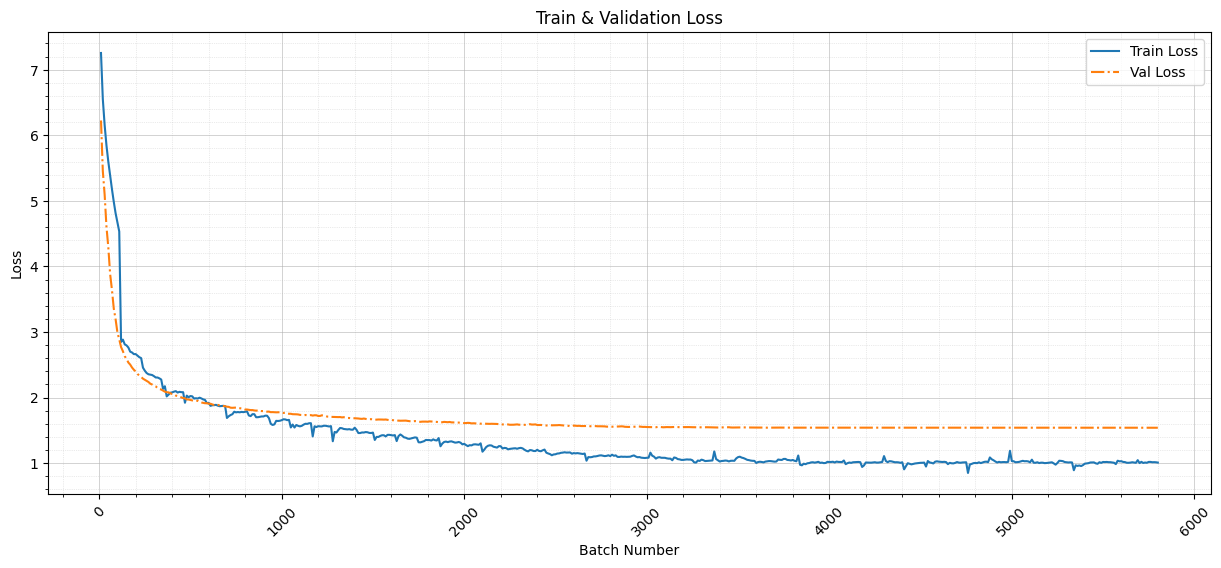

In [26]:
# -- Plot training and validation loss vs batch number ------------------------------------------------------
import matplotlib.pyplot as plt

def plot_train_val_loss(batches_seen, train_losses, val_losses):
    logger.info("Generating plot: training and validation loss vs batch number.")

    fig, ax1 = plt.subplots(figsize=(15,6))

    # Plot training and validation loss against epochs
    ax1.plot(batches_seen, train_losses, label="Train Loss")
    ax1.plot(batches_seen, val_losses, linestyle="-.", label="Val Loss")
    ax1.set_xlabel("Batch Number")
    #ax1.set_ylim(0)
    ax1.set_ylabel("Loss")
    ax1.set_title("Train & Validation Loss")
    ax1.legend(loc="upper right")
    # --- Add Subgrid (Minor Grid Lines) ---
    ax1.minorticks_on()  # Enable minor ticks
    # Major grid (main grid lines)
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.8)
    # Minor grid (subgrid lines)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax1.grid(True)

    #fig.tight_layout()  # Adjust layout to make room
    plt.xticks(rotation=45)
    plt.savefig(f"loss-plot-finetune-instruction-{run_id}.pdf")
    plt.show()

plot_train_val_loss(batches_seen, train_losses, val_losses)

In [27]:
# # 1) Specify device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 2) (Re)load your fine-tuned model
# #    → this model’s lm_head was replaced with Linear(n_embd=1024, out_features=2)
# model = GPTLanguageModel(
#     vocab_size=50304,
#     block_size=1024,
#     n_embd=1024,
#     n_head=16,
#     n_layer=24,
#     dropout=0.1,
#     device=device
# ).to(device)

# # ---- Load Best Model for Final Test ----
# logger.info(f"Loading best model from: {best_model_path}")
# ckpt_data = torch.load(best_model_path, map_location=device)
# model.load_state_dict(ckpt_data["model_state_dict"])
# model.to(device)
# model.eval()

# # ---- Final Test Evaluation ----
# with torch.no_grad():
#     final_test_loss = calc_loss_loader(test_loader, model, device, num_batches=None)

# logger.info(f"📊 Final Test Loss (best model): {final_test_loss:.4f}")


In [28]:


sample_prompt = format_input(test_loader.dataset.data[0])  # assume dataset stores `.data`
model.eval()
with torch.no_grad():
    input_ids = torch.tensor(tokenizer.encode(sample_prompt), dtype=torch.long)\
                .unsqueeze(0).to(device)
    generated = model.advanced_generation(
        input_ids,
        max_new_tokens=50,
        temperature=1.0,
        top_k=50
    )
prompt_len = len(tokenizer.encode(sample_prompt))
response_ids = generated[0][prompt_len:].tolist()
decoded_resp = tokenizer.decode(response_ids)
logger.info(f"Sample response:\n{decoded_resp}")

22:39:41 [INFO] Sample response:


### Response:
The melting of 2 degrees Celsius is 9th.<|endoftext|>


In [29]:
sample_prompt


'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat is the formula for density?'